In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go


%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [43]:
superstore_sales = pd.read_excel('US Superstore data.xls')
superstore_sales.sample(8)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
7791,7792,CA-2016-108364,2016-12-19,2016-12-24,Standard Class,BP-11050,Barry Pond,Corporate,United States,Chicago,...,60623,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,1.800,5,0.8,-2.8800
4832,4833,CA-2014-120278,2014-11-07,2014-11-12,Standard Class,MS-17365,Maribeth Schnelling,Consumer,United States,Wausau,...,54401,Central,OFF-ST-10002214,Office Supplies,Storage,X-Rack File for Hanging Folders,22.580,2,0.0,5.8708
4434,4435,CA-2016-168893,2016-11-03,2016-11-08,Second Class,AP-10915,Arthur Prichep,Consumer,United States,Henderson,...,42420,South,FUR-TA-10003392,Furniture,Tables,Global Adaptabilities Conference Tables,842.940,3,0.0,160.1586
5806,5807,CA-2016-149783,2016-09-04,2016-09-07,Second Class,DL-13315,Delfina Latchford,Consumer,United States,Knoxville,...,37918,South,OFF-PA-10002195,Office Supplies,Paper,"RSVP Cards & Envelopes, Blank White, 8-1/2"" X ...",12.192,3,0.2,4.1148
9271,9272,CA-2016-100510,2016-05-12,2016-05-17,Standard Class,HM-14860,Harry Marie,Corporate,United States,New York City,...,10024,East,FUR-FU-10000320,Furniture,Furnishings,OIC Stacking Trays,10.020,3,0.0,4.4088
1047,1048,CA-2016-169103,2016-03-08,2016-03-13,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,United States,Miami,...,33142,South,FUR-FU-10004006,Furniture,Furnishings,"Deflect-o DuraMat Lighweight, Studded, Beveled...",102.360,3,0.2,-3.8385
7455,7456,CA-2016-137743,2016-07-30,2016-08-04,Standard Class,KH-16360,Katherine Hughes,Consumer,United States,Chicago,...,60623,Central,OFF-ST-10001780,Office Supplies,Storage,Tennsco 16-Compartment Lockers with Coat Rack,1036.624,2,0.2,51.8312
1881,1882,CA-2015-109512,2015-03-05,2015-03-05,Same Day,LF-17185,Luke Foster,Consumer,United States,New York City,...,10011,East,FUR-CH-10001146,Furniture,Chairs,"Global Value Mid-Back Manager's Chair, Gray",383.607,7,0.1,63.9345



#EXPLORATORY DATA

In [3]:
df = superstore_sales.copy()

In [4]:
df.shape

(9994, 21)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [7]:
df[['Sales','Discount','Profit','Quantity']].describe()

,Sales,Discount,Profit,Quantity
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,0.156203,28.656896,3.789574
std,623.245101,0.206452,234.260108,2.225110
min,0.444000,0.000000,-6599.978000,1.000000
25%,17.280000,0.000000,1.728750,2.000000
50%,54.490000,0.200000,8.666500,3.000000
75%,209.940000,0.200000,29.364000,5.000000
max,22638.480000,0.800000,8399.976000,14.000000


In [8]:
df=df.drop('Row ID',axis=1)

In [9]:
df['Country'].value_counts()

,count
Country,
United States,9994


In [10]:
df=df.drop('Country',axis=1)

In [11]:
df.drop(['Order ID',         'Ship Date',          'Ship Mode',          'Customer ID',          'Customer Name',          'Postal Code',         'Product ID',          'Product Name'],         axis=1, inplace = True)

In [12]:
df.shape

(9994, 11)

In [13]:
category_counts = df['Category'].value_counts()
category_counts

,count
Category,
Office Supplies,6026
Furniture,2121
Technology,1847


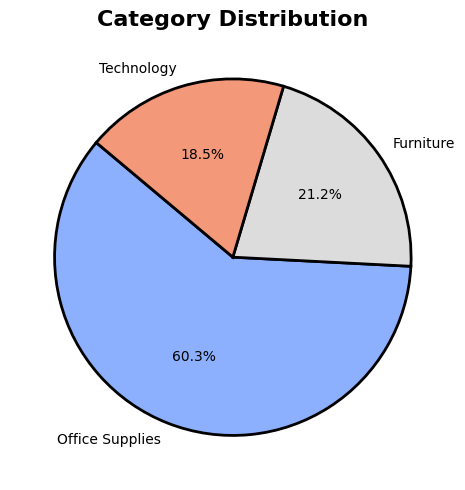

In [14]:
fig, axs = plt.subplots(figsize=(5, 5))

axs.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('coolwarm', len(category_counts)),
    wedgeprops={'edgecolor': 'black', 'linewidth': 2}
)

axs.set_title('Category Distribution', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

Category Distribution (Pie Chart)


The pie chart shows how your data is distributed across different product categories.
One or two categories likely dominate the dataset, contributing the largest share.
Smaller slices indicate less frequent categories or lower representation.
This helps quickly identify which category is most common or important in your dataset.

Insight:
If one category is significantly larger, your business/data is heavily dependent on that segment.
Balanced slices indicate diversification across categories.

In [15]:
import plotly.express as px

fig = px.sunburst(
    df,
    path=['Category', 'Sub-Category'],
    values='Sales',
    color='Category',
    hover_data=['Sales', 'Quantity', 'Profit']
)

fig.update_layout(
    height=1000,
    title_text='Product Categories & Sub-Categories'
)

fig.show()

Category → Sub-Category (Sunburst Chart)

The sunburst chart gives a hierarchical breakdown:
Inner ring → Category
Outer ring → Sub-Category
The size of each segment represents Sales contribution.
Hovering shows detailed metrics like Sales, Quantity, and Profit.

Insight:
One can identify Which sub-categories drive the most sales
Which ones contribute less (or may need improvement)
It reveals hidden patterns not visible in the pie chart (like which sub-category dominates inside a category)

In [16]:
import plotly.graph_objects as go
from plotly.offline import iplot

data = go.Pie(
    labels=df['Sub-Category'].value_counts().index,
    values=df['Sub-Category'].value_counts(),
    textinfo='label+percent',
    hoverinfo='label+percent',
    marker=dict(line=dict(width=1.5))
)

layout = go.Layout(
    title='Pie Plot for Total Sales for each Sub-Category',
    titlefont=dict(size=25),
    height=1000
)

iplot(dict(data=[data], layout=layout))

Review of sales and profits

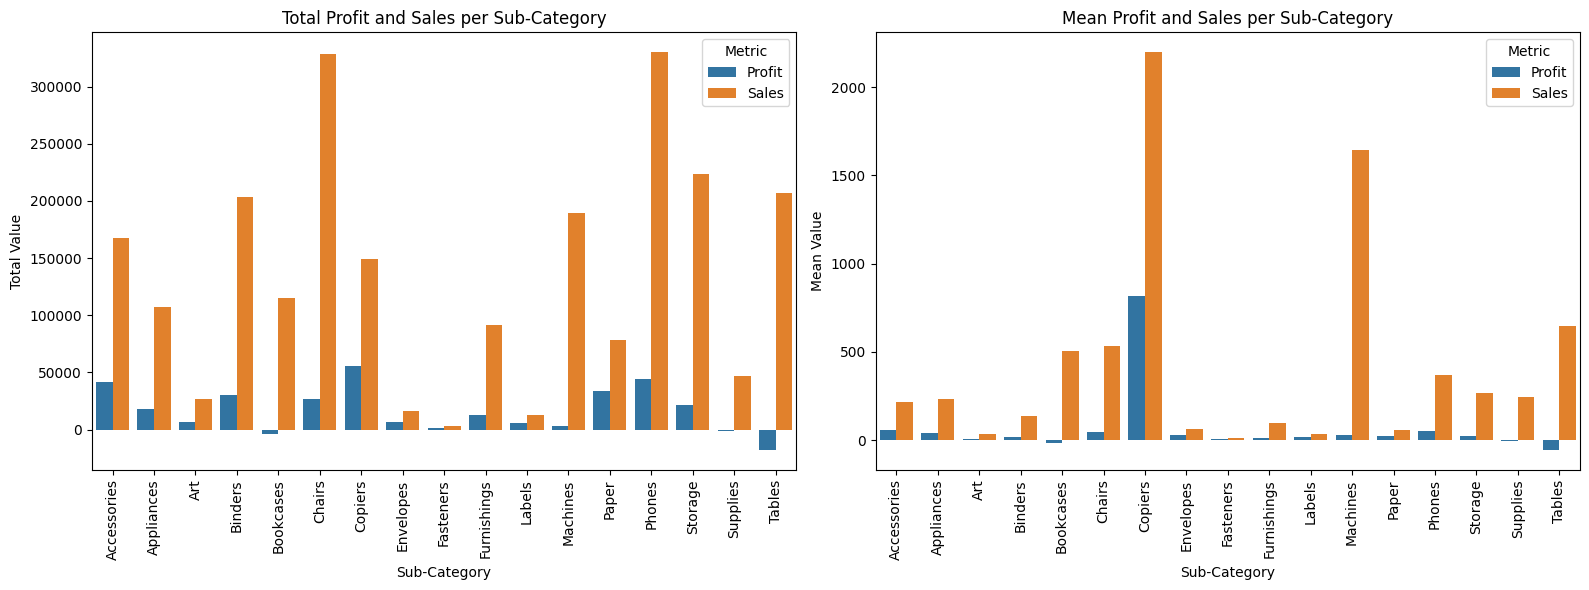

In [17]:
# Grouping
grouped_sum = df.groupby('Sub-Category')[['Profit', 'Sales']].sum().reset_index()
grouped_mean = df.groupby('Sub-Category')[['Profit', 'Sales']].mean().reset_index()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total values plot
sns.barplot(
    data=grouped_sum.melt(id_vars='Sub-Category', var_name='Metric', value_name='Value'),
    x='Sub-Category',
    y='Value',
    hue='Metric',
    ax=axes[0]
)
axes[0].set_title('Total Profit and Sales per Sub-Category')
axes[0].set_ylabel('Total Value')
axes[0].tick_params(axis='x', rotation=90)

# Mean values plot
sns.barplot(
    data=grouped_mean.melt(id_vars='Sub-Category', var_name='Metric', value_name='Value'),
    x='Sub-Category',
    y='Value',
    hue='Metric',
    ax=axes[1]
)
axes[1].set_title('Mean Profit and Sales per Sub-Category')
axes[1].set_ylabel('Mean Value')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

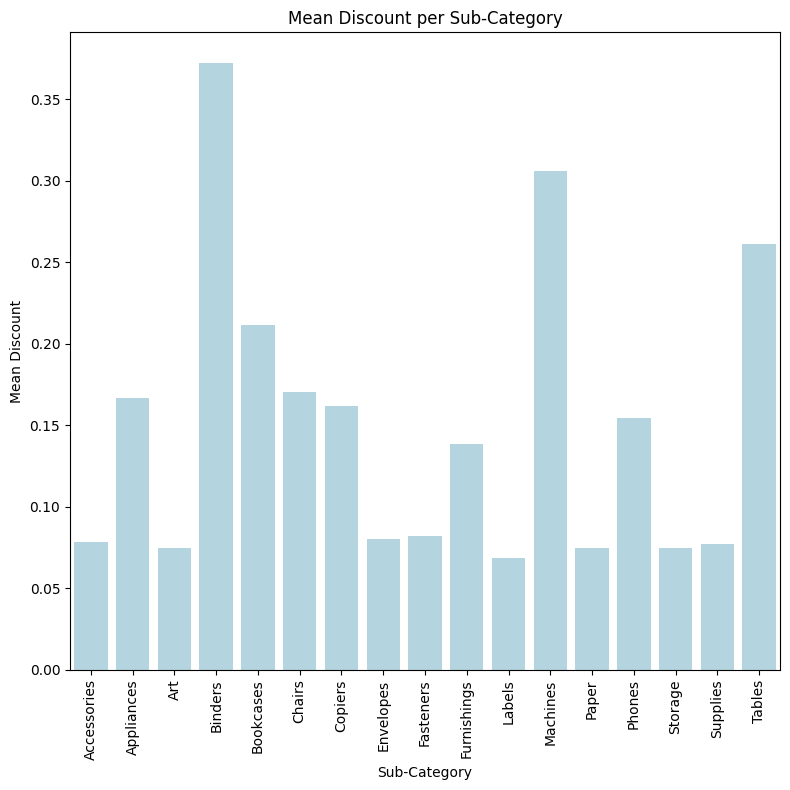

In [18]:
grouped_discount_mean = df.groupby('Sub-Category')['Discount'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 8))

sns.barplot(
    data=grouped_discount_mean,
    x='Sub-Category',
    y='Discount',
    ax=ax,
    color='lightblue'
)

ax.set_title('Mean Discount per Sub-Category')
ax.set_ylabel('Mean Discount')
ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

;

Review of the sales of different parts of the US

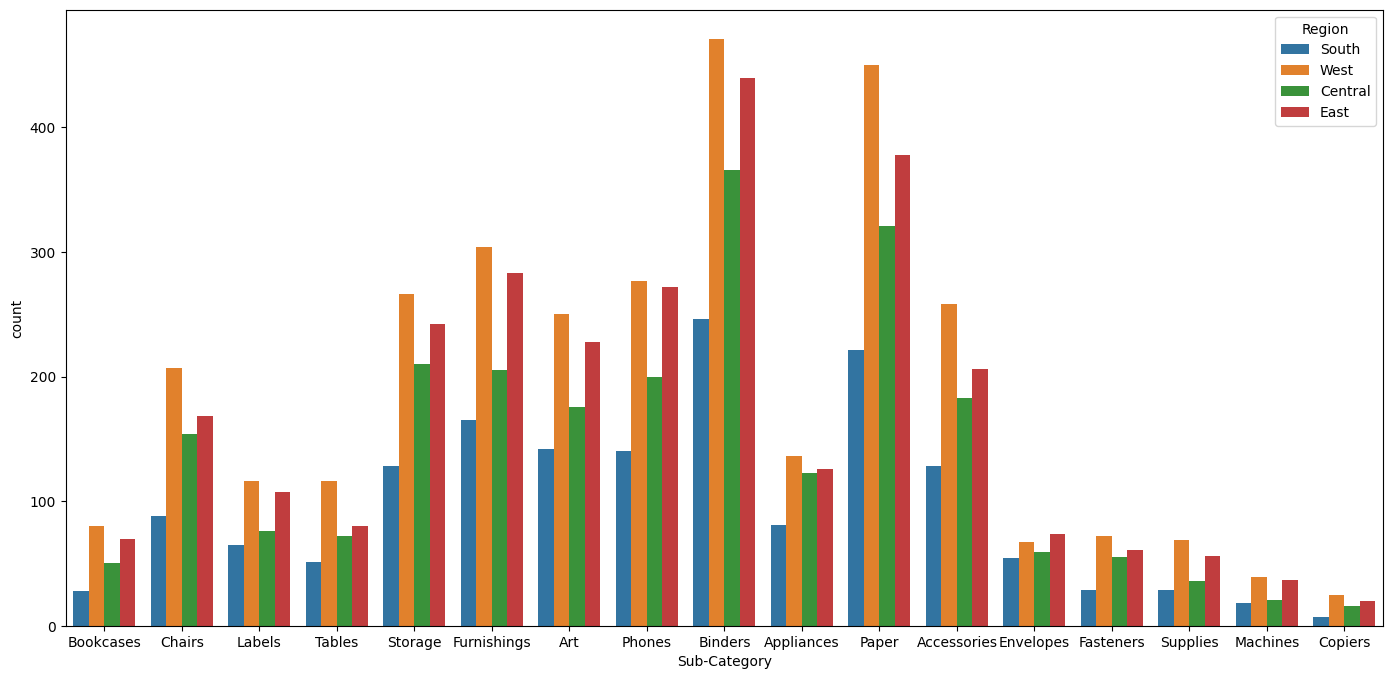

In [19]:
plt.figure(figsize=(17,8))
sns.countplot(x="Sub-Category", hue="Region", data=df)
plt.show()


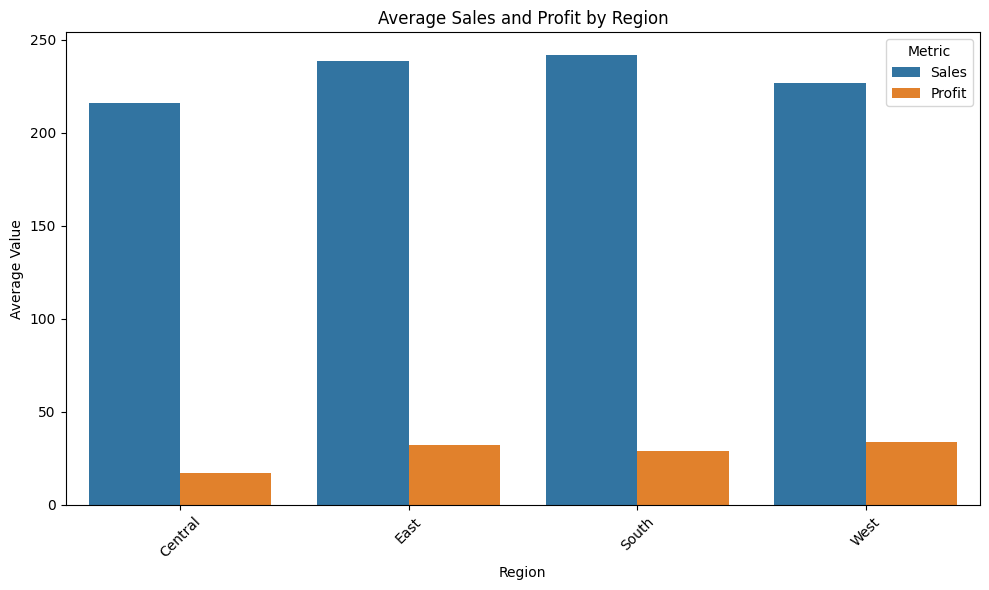

In [20]:
grouped_data = df.groupby('Region')[['Sales', 'Profit']].mean().reset_index()

melted_data = grouped_data.melt(
    id_vars='Region',
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=melted_data,
    x='Region',
    y='Value',
    hue='Metric'
)

plt.title('Average Sales and Profit by Region')
plt.ylabel('Average Value')
plt.xlabel('Region')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

lll

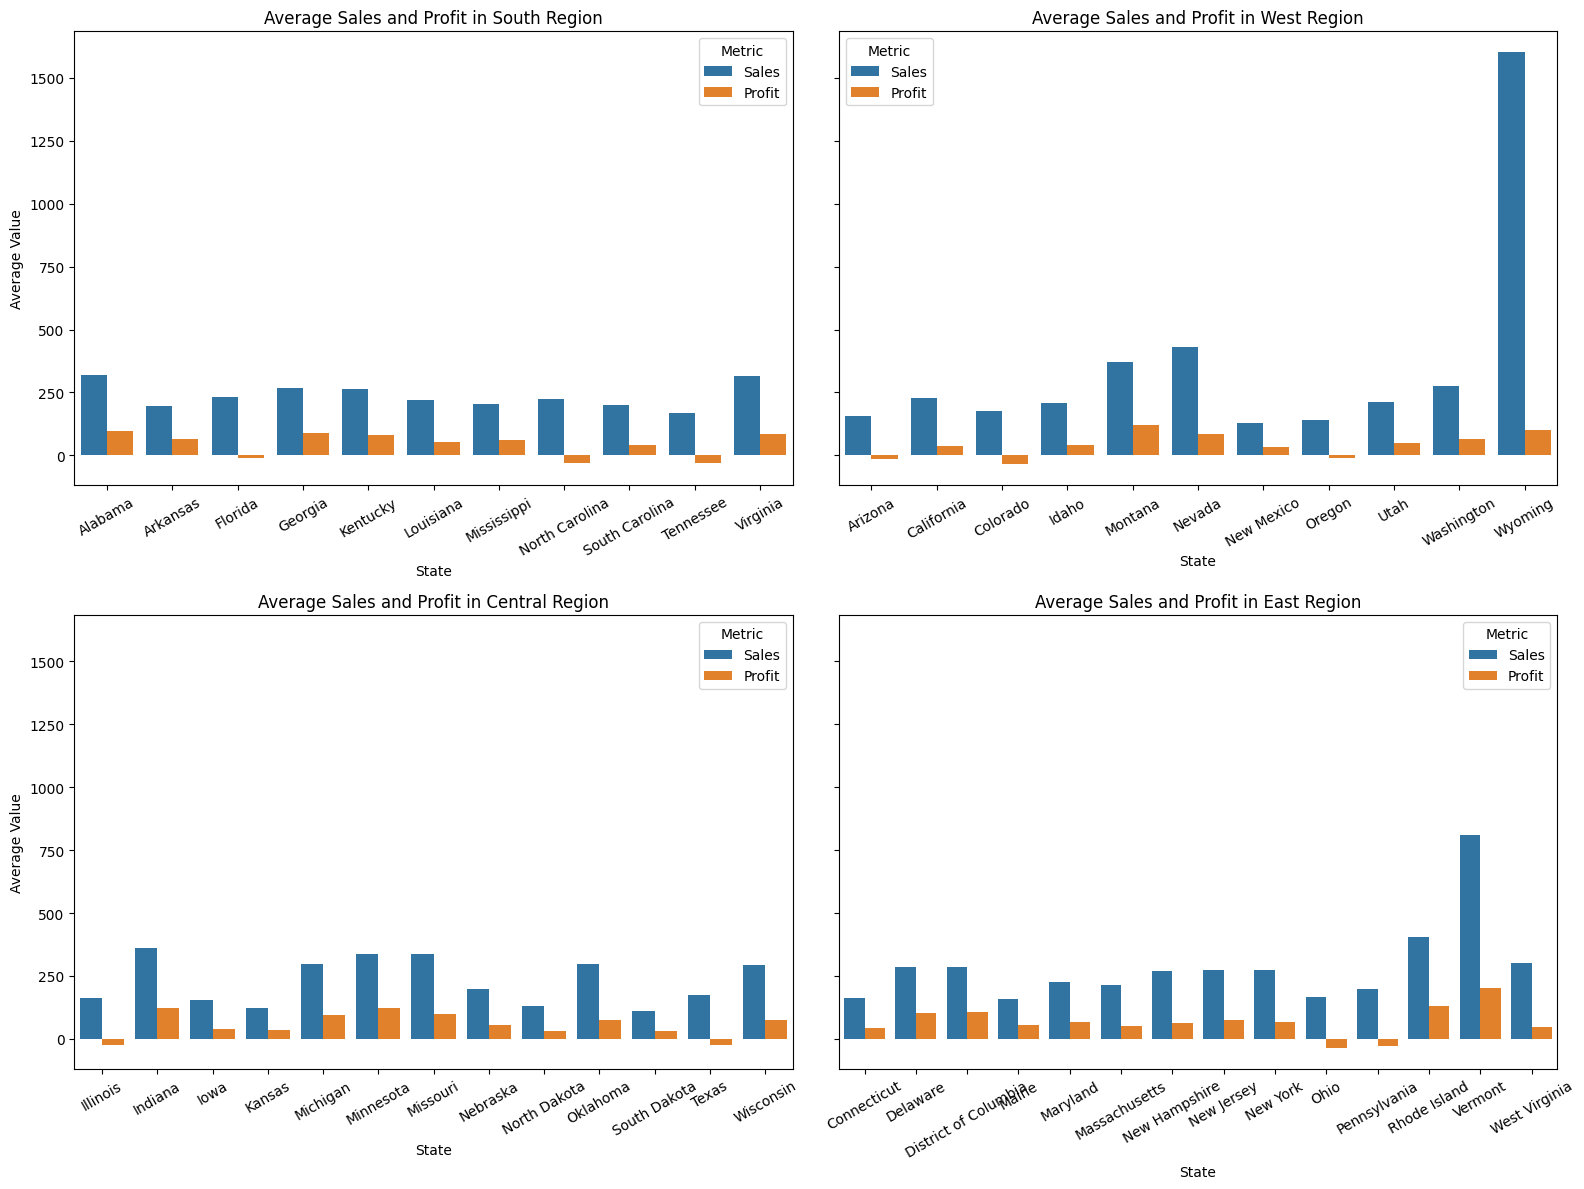

In [21]:
regions = df['Region'].unique()

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten()

for i in range(4):
    df_region = df[df['Region'] == regions[i]].copy()

    grouped_data = df_region.groupby('State')[['Sales', 'Profit']].mean().reset_index()

    melted_data = grouped_data.melt(
        id_vars='State',
        var_name='Metric',
        value_name='Value'
    )

    sns.barplot(
        data=melted_data,
        x='State',
        y='Value',
        hue='Metric',
        ax=axes[i]
    )

    axes[i].set_title(f'Average Sales and Profit in {regions[i]} Region')
    axes[i].set_ylabel('Average Value')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Metric')

plt.tight_layout()
plt.show()

In [22]:
import plotly.express as px

temp = df[['State', 'City', 'Sales']] \
    .groupby(['State', 'City'])['Sales'] \
    .sum() \
    .reset_index()

fig = px.treemap(
    temp,
    path=['State', 'City'],
    values='Sales'
)

fig.update_layout(
    height=1000,
    title='City-wise Sales'

)

fig.data[0].textinfo = 'label+text+value'

fig.show()

In [23]:

temp = df[['State', 'City', 'Sales']] \
    .groupby(['State', 'City'])['Sales'] \
    .sum() \
    .reset_index()

fig = px.treemap(
    temp,
    path=['State', 'City'],
    values='Sales',
    color='Sales',
    color_continuous_scale='Blues',
    title='City-wise Sales Distribution'
)

fig.update_layout(
    height=1000
)


fig.data[0].textinfo = 'label+value+percent entry'

fig.update_traces(
    hovertemplate='<b>%{label}</b><br>Sales: %{value}<br>Share: %{percentEntry:.2%}<extra></extra>'
)

fig.show()

uuuu


In [24]:
df_notime = df[['Segment', 'City', 'State', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']].copy()

In [25]:
df

,Order Date,Segment,City,State,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,2016-11-08,Consumer,Henderson,Kentucky,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,2016-11-08,Consumer,Henderson,Kentucky,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,2016-06-12,Corporate,Los Angeles,California,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,2015-10-11,Consumer,Fort Lauderdale,Florida,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,2015-10-11,Consumer,Fort Lauderdale,Florida,South,Office Supplies,Storage,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...
9989,2014-01-21,Consumer,Miami,Florida,South,Furniture,Furnishings,25.2480,3,0.20,4.1028
9990,2017-02-26,Consumer,Costa Mesa,California,West,Furniture,Furnishings,91.9600,2,0.00,15.6332
9991,2017-02-26,Consumer,Costa Mesa,California,West,Technology,Phones,258.5760,2,0.20,19.3932
9992,2017-02-26,Consumer,Costa Mesa,California,West,Office Supplies,Paper,29.6000,4,0.00,13.3200


In [26]:
state_data = df_notime.groupby('State').sum().reset_index()

fig = px.scatter(
    state_data,
    x='Sales',
    y='Profit',
    size='Quantity',
    hover_name='State',
    title='Sales & Profits by States'
)

fig.show()

In [27]:
#Advanced Analysis

state_data = df_notime.groupby('State').sum().reset_index()

fig = go.Figure(
    data=go.Scatter(
        x=state_data['Sales'],
        y=state_data['Profit'],
        mode='markers',
        text=state_data['State'],
        marker=dict(
            size=state_data['Quantity'],
            sizemode='area',
            sizeref=2.*max(state_data['Quantity'])/(100.**2),
            showscale=True
        )
    )
)

fig.update_layout(
    title='Sales & Profits by States',
    title_font=dict(size=25),
    xaxis=dict(title='Sales', title_font=dict(size=18)),
    yaxis=dict(title='Profits', title_font=dict(size=18))
)

fig.show()

Discount Analysis

In [28]:
discount_counts = df_notime['Discount'].value_counts().sort_values(ascending=False)


top_n = 6
top_discounts = discount_counts.head(top_n)
others = discount_counts.iloc[top_n:].sum()


values = list(top_discounts.values)
labels = [f"{int(d*100)}% Discount" for d in top_discounts.index]

if others > 0:
    values.append(others)
    labels.append('Others')


fig = go.Figure(
    data=[go.Pie(
        labels=labels,
        values=values,
        hole=0.4,
        textinfo='label+percent',
        hoverinfo='label+percent+value',
        marker=dict(line=dict(width=1.5)),
        pull=[0.1 if i == 0 else 0 for i in range(len(labels))]
    )]
)

fig.update_layout(
    title='Discount Distribution (Top Discounts Highlighted)',
    title_font=dict(size=22)
)

fig.show()

In [29]:
discount_counts = df_notime['Discount'].value_counts().sort_index()

A few discount levels dominate most transactions

Remaining discount levels contribute relatively less and are grouped as “Others”

Helps identify most frequently used pricing strategies

In [30]:
import plotly.graph_objects as go

data = [
    go.Histogram(
        x=df_notime.sort_values('Discount')['Discount']
    )
]

layout = go.Layout(
    title='Sales Histogram Plot For Each Discount',
    xaxis=dict(
        title='Discount',
        title_font=dict(size=20)
    )
)

fig = dict(data=data, layout=layout)

iplot(fig)

In [31]:

from plotly.subplots import make_subplots

fig = make_subplots(
    rows=6,
    cols=2,
    subplot_titles=[
        '0% Discount','10% Discount','15% Discount',
        '20% Discount','30% Discount','32% Discount',
        '40% Discount','45% Discount','50% Discount',
        '60% Discount','70% Discount','80% Discount'
    ],
    horizontal_spacing=0.1,
    vertical_spacing=0.1
)

fig.add_trace(go.Histogram(x=df_notime[df_notime['Discount']==0]['Sales'], name='0% Distribution'), row=1, col=1)
fig.add_trace(go.Histogram(x=df_notime[df_notime['Discount']==0.1]['Sales'], name='10% Distribution'), row=1, col=2)

fig.add_trace(go.Histogram(x=df_notime[df_notime['Discount']==0.15]['Sales'], name='15% Distribution'), row=2, col=1)
fig.add_trace(go.Histogram(x=df_notime[df_notime['Discount']==0.2]['Sales'], name='20% Distribution'), row=2, col=2)

fig.add_trace(go.Histogram(x=df_notime[df_notime['Discount']==0.3]['Sales'], name='30% Distribution'), row=3, col=1)
fig.add_trace(go.Histogram(x=df_notime[df_notime['Discount']==0.32]['Sales'], name='32% Distribution'), row=3, col=2)

fig.add_trace(go.Histogram(x=df_notime[df_notime['Discount']==0.4]['Sales'], name='40% Distribution'), row=4, col=1)
fig.add_trace(go.Histogram(x=df_notime[df_notime['Discount']==0.45]['Sales'], name='45% Distribution'), row=4, col=2)

fig.add_trace(go.Histogram(x=df_notime[df_notime['Discount']==0.5]['Sales'], name='50% Distribution'), row=5, col=1)
fig.add_trace(go.Histogram(x=df_notime[df_notime['Discount']==0.6]['Sales'], name='60% Distribution'), row=5, col=2)

fig.add_trace(go.Histogram(x=df_notime[df_notime['Discount']==0.7]['Sales'], name='70% Distribution'), row=6, col=1)
fig.add_trace(go.Histogram(x=df_notime[df_notime['Discount']==0.8]['Sales'], name='80% Distribution'), row=6, col=2)

fig.update_layout(
    width=2000,
    height=1000,
    title_text='Sales Distribution by Discount Levels',
    showlegend=False
)

fig.show()

By applying the right policy on discounts,the loss of the store can be avoided in some sections

#SEGMENTATION

In [32]:
!pip install squarify

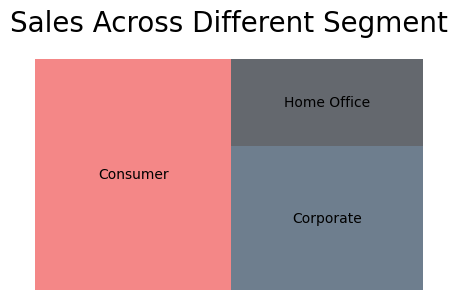

In [33]:
import squarify

df_tree = df[['Segment', 'Sales']]
df_tree = df_tree.groupby(['Segment']).sum().reset_index()

plt.figure(figsize=(5, 3))

squarify.plot(
    sizes=df_tree['Sales'],
    label=df_tree['Segment'],
    color=['#F05454', '#30475E', '#222831'],
    alpha=0.7
)

plt.title("Sales Across Different Segment", size=20, pad=20)
plt.axis('off')

plt.show()

In [34]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go


segments = df['Segment'].unique()


total_sales = [df[df['Segment'] == i]['Sales'].sum() for i in segments]
average_sales = [df[df['Segment'] == i]['Sales'].mean() for i in segments]


fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        'Total Sales of Each Segment',
        'Average Sales of Each Segment'
    ]
)


fig.add_trace(
    go.Bar(
        x=segments,
        y=total_sales,
        marker_color='rgb(171,241,255)',
        marker_line_color='rgb(12,0,235)',
        marker_line_width=2,
        opacity=0.6
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=segments,
        y=average_sales,
        marker_color='rgb(171,241,255)',
        marker_line_color='rgb(12,0,235)',
        marker_line_width=2,
        opacity=0.6
    ),
    row=1, col=2
)


fig.update_layout(
    template='simple_white',
    title='Sales Analysis by Segment',
    title_font_size=20,
    showlegend=False
)

fig.show()

In [35]:
total_profit = [df[df['Segment'] == i]['Profit'].sum() for i in segments]
average_profit = [df[df['Segment'] == i]['Profit'].mean() for i in segments]


fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        'Total Profit of Each Segment',
        'Average Profit of Each Segment'
    ]
)

fig.add_trace(
    go.Bar(
        x=segments,
        y=total_profit,
        marker_color='rgb(255,183,183)',
        marker_line_color='rgb(200,0,0)',
        marker_line_width=2,
        opacity=0.6
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=segments,
        y=average_profit,
        marker_color='rgb(255,183,183)',
        marker_line_color='rgb(200,0,0)',
        marker_line_width=2,
        opacity=0.6
    ),
    row=1, col=2
)

fig.update_layout(
    template='simple_white',
    title='Profit Analysis by Segment',
    title_font_size=20,
    showlegend=False
)

fig.show()

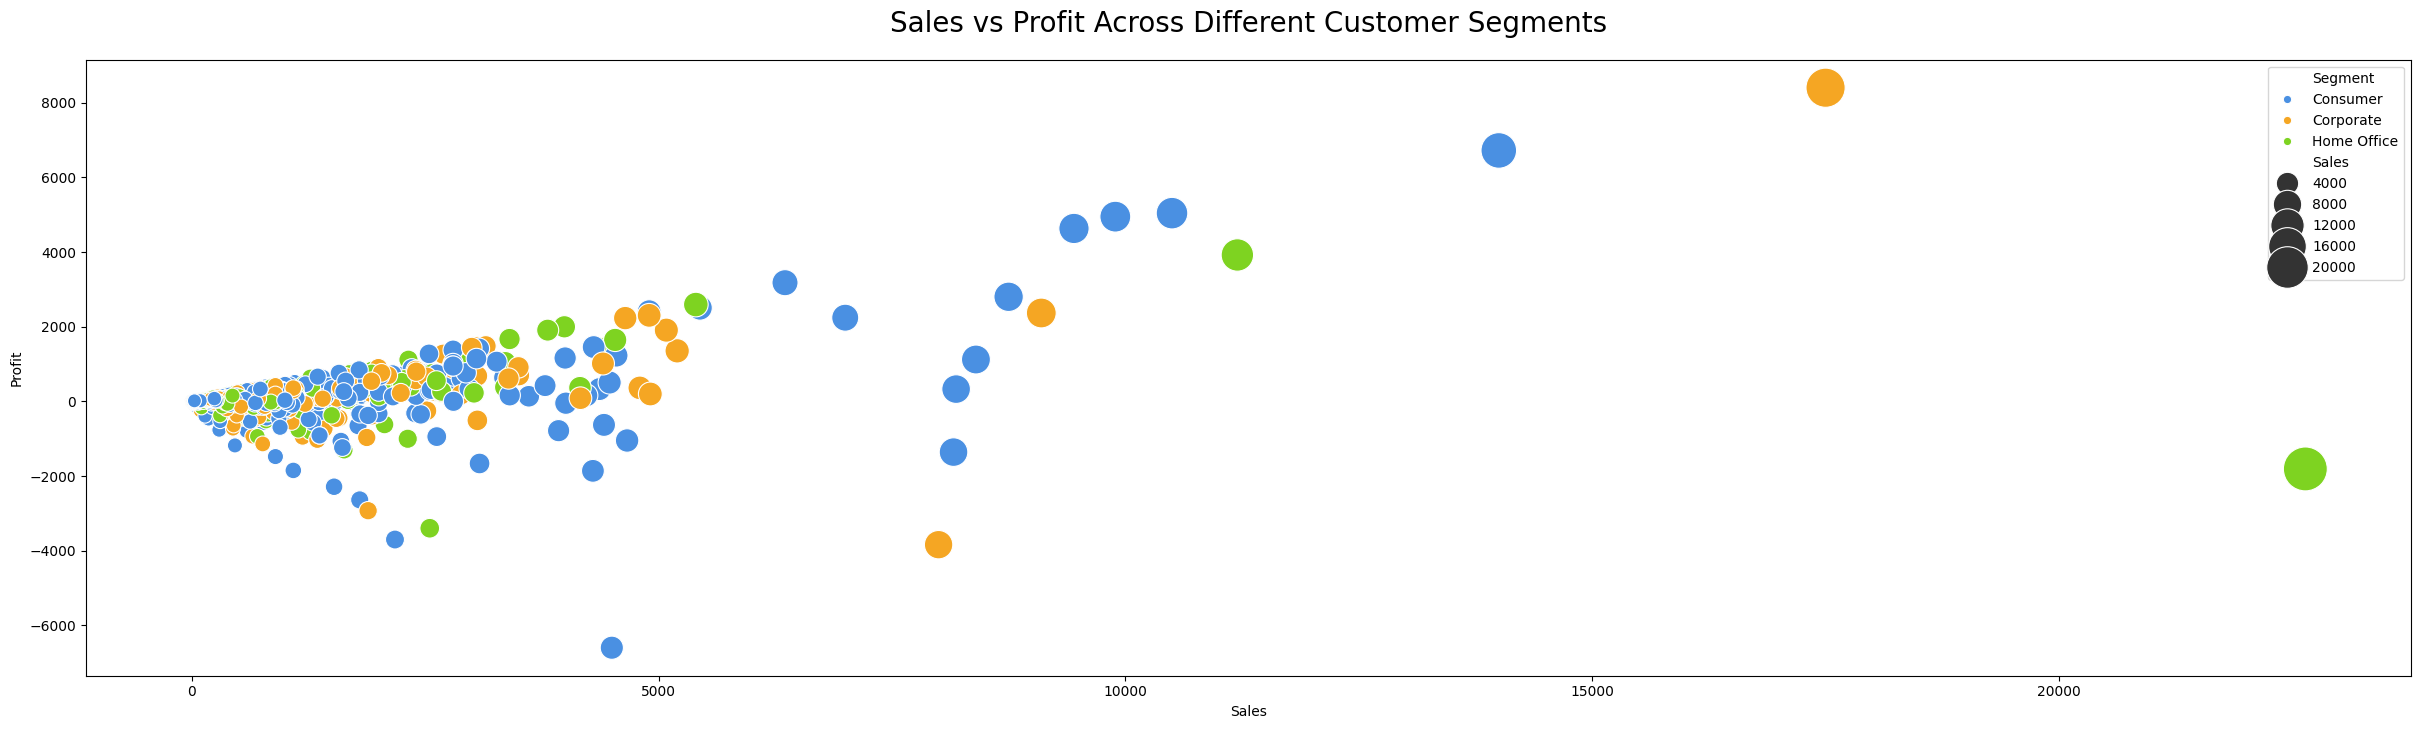

In [36]:

df_scatter = df[['Sales', 'Profit', 'Segment']].copy()


plt.figure(figsize=(30, 8))

sns.scatterplot(
    x=df_scatter['Sales'],
    y=df_scatter['Profit'],
    hue=df_scatter['Segment'],
    palette=['#4A90E2', '#F5A623', '#7ED321'],
    size=df_scatter['Sales'],
    sizes=(100, 1000),
    legend='auto'
)

plt.title("Sales vs Profit Across Different Customer Segments", size=20, pad=20)

plt.show()

sllla


Analyze the Orders & Sales

In [37]:
df_grouped = df.groupby('Segment').agg({
    'Sales': 'sum',
    'Profit': ['sum', 'mean']
}).reset_index()

df_grouped.columns = ['Segment', 'Total Sales', 'Total Profit', 'Avg Profit']


fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "bar"}, {"type": "bar"}],
           [{"type": "scatter"}, {"type": "domain"}]],
    subplot_titles=[
        "Total Sales by Segment",
        "Total Profit by Segment",
        "Sales vs Profit",
        "Segment Contribution (Treemap)"
    ]
)


fig.add_trace(
    go.Bar(
        x=df_grouped['Segment'],
        y=df_grouped['Total Sales'],
        marker=dict(color='skyblue'),
        text=df_grouped['Total Sales'],
        textposition='outside'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=df_grouped['Segment'],
        y=df_grouped['Total Profit'],
        marker=dict(color='salmon'),
        text=df_grouped['Total Profit'],
        textposition='outside'
    ),
    row=1, col=2
)


fig.add_trace(
    go.Scatter(
        x=df['Sales'],
        y=df['Profit'],
        mode='markers',
        marker=dict(
            size=df['Sales']/50,
            color=df['Profit'],
            colorscale='Viridis',
            showscale=True
        ),
        text=df['Segment']
    ),
    row=2, col=1
)


treemap = px.treemap(
    df,
    path=['Segment'],
    values='Sales'
)

fig.add_trace(
    treemap.data[0],
    row=2, col=2
)

fig.update_layout(
    height=900,
    width=1200,
    title_text="Sales & Profit Dashboard",
    template="plotly_white",
    showlegend=False
)

fig.show()

In [38]:

df_time = df[['Order Date', 'Segment', 'Sales', 'Quantity', 'Discount', 'Profit']].copy()

df_time['Month_Name'] = df_time['Order Date'].dt.month_name()
df_time['Year_Month'] = df_time['Order Date'].dt.to_period('M')

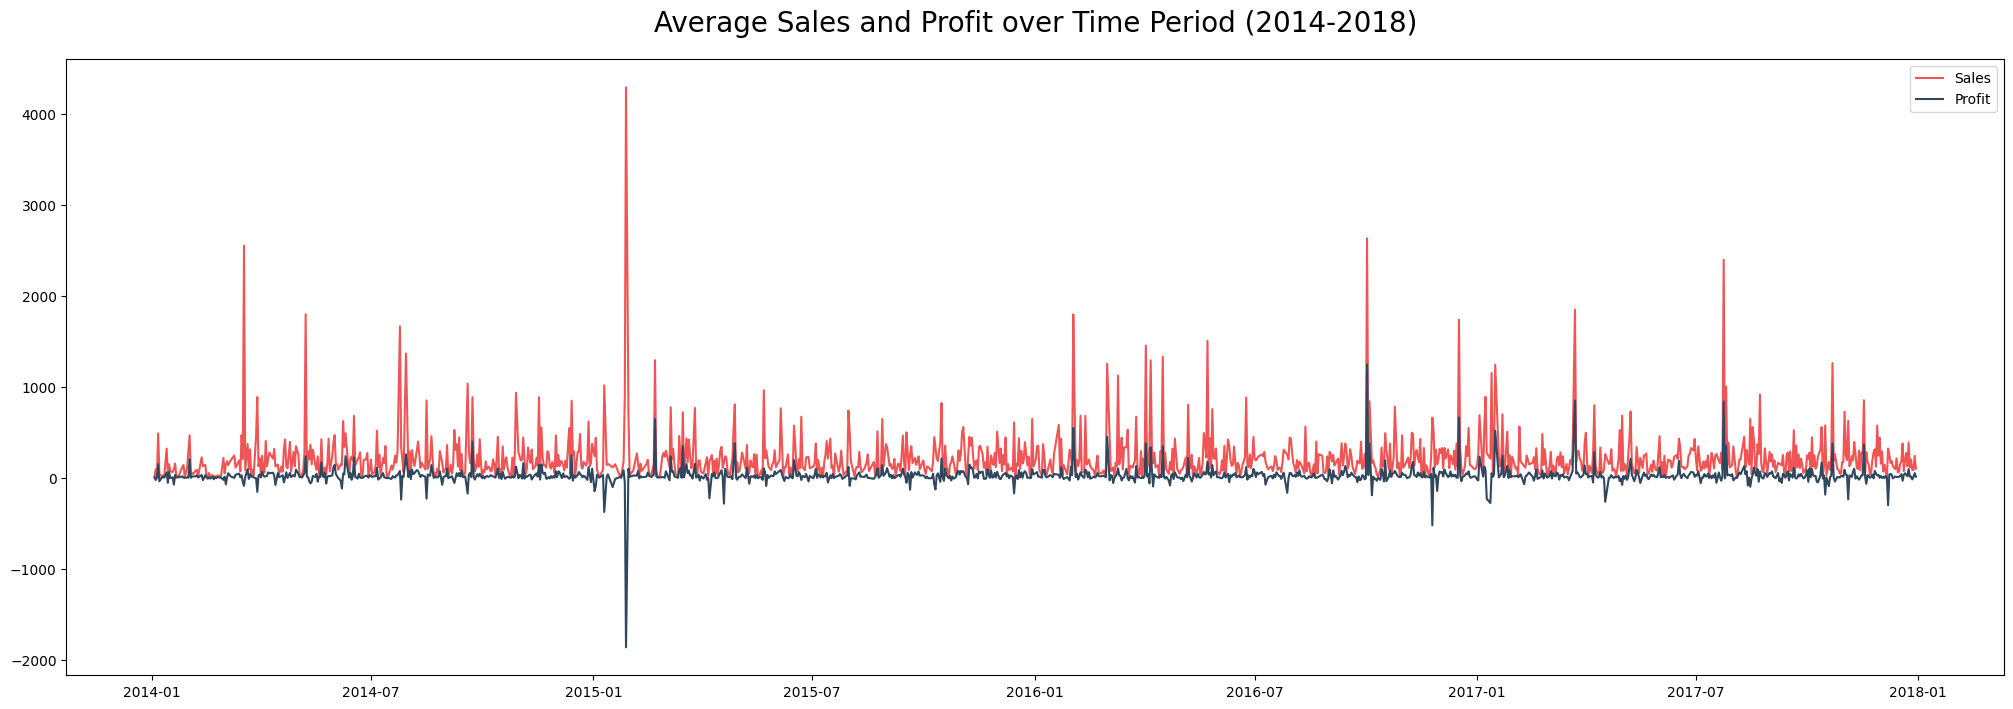

In [39]:

df_line = df_time[['Order Date', 'Sales', 'Profit']].sort_values('Order Date')

df_line['Order Date'] = pd.to_datetime(df_line['Order Date'])

df_line = df_line.groupby('Order Date').mean()

plt.figure(figsize=(25, 8))

plt.plot(df_line.index, df_line['Sales'], color='#F05454', label='Sales')
plt.plot(df_line.index, df_line['Profit'], color='#30475E', label='Profit')

plt.title("Average Sales and Profit over Time Period (2014-2018)", size=20, pad=20)

plt.legend()
plt.show()

In [40]:
df_time['Order Date'] = pd.to_datetime(df_time['Order Date'])

df_time['Year'] = df_time['Order Date'].dt.year
df_time['Month'] = df_time['Order Date'].dt.month

In [41]:
print(df_time.columns)

Index(['Order Date', 'Segment', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Month_Name', 'Year_Month', 'Year', 'Month'],
      dtype='object')


In [42]:
import calendar
monthly_sales['Month_Name'] = monthly_sales['Month'].apply(lambda x: calendar.month_abbr[x])
avg_monthly_sales['Month_Name'] = avg_monthly_sales['Month'].apply(lambda x: calendar.month_abbr[x])

NameError: name 'monthly_sales' is not defined

In [ ]:
monthly_sales = df_time.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

avg_monthly_sales = monthly_sales.groupby('Month')['Sales'].mean().reset_index()

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharey=True)
axes = axes.flatten()

for i in range(3):

    monthly_sales = df_time[df_time['Segment'] == segments[i]] \
        .groupby(['Year', 'Month'])['Sales'].sum().reset_index()

    avg_monthly_sales = monthly_sales.groupby('Month')['Sales'].mean().reset_index()


    sns.lineplot(
        data=monthly_sales,
        x='Month',
        y='Sales',
        hue='Year',
        marker='o',
        palette='Set1',
        ax=axes[i]
    )


    sns.lineplot(
        data=avg_monthly_sales,
        x='Month',
        y='Sales',
        label='Average',
        color='black',
        linestyle='--',
        marker='o',
        ax=axes[i]
    )


    axes[i].set_title(f'Average Sales for {segments[i]}')
    axes[i].set_ylabel('Sales')
    axes[i].grid(True)
    axes[i].legend(title='Legend')


plt.tight_layout()
plt.show()

The analysis of store sales data reveals a strong seasonal pattern in customer purchasing behavior. Sales peak during March, September, November, and December, with an estimated increase of 20–40% above the monthly average, indicating the influence of promotional campaigns, festive seasons, and year-end demand cycles.

In contrast, sales decline during January, February, and October, showing a drop of approximately 15–30% below average, likely due to post-holiday slowdowns and reduced consumer activity.

Segment-wise analysis indicates that the Corporate and Home Office segments contribute consistently, accounting for a stable share of total sales throughout the year. These segments exhibit low variance in monthly performance, reflecting steady business-driven demand. However, both segments experience a slight dip in January, with an estimated 10–15% decrease, likely due to slower business operations at the beginning of the year.

Key Insights:

Peak Months: Mar, Sep, Nov, Dec
Sales by 20–40%


Low Months: Jan, Feb, Oct
Sales by 15–30%
Strong seasonality pattern


Segment Insights:
Corporate & Home Office:
Stable demand (low fluctuation)
Consistent contribution
January dip (~10–15%)